In [1]:
# CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# CELL 2: Load Data
df = pd.read_csv('post natal data.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1503, 11)


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [3]:
# CELL 3: Check Missing Values
df.isnull().sum()

Timestamp                                     0
Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

In [4]:
# CELL 4: Basic Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad or Tearful                     1503 non-null   object
 3   Irritable towards baby & partner           1497 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1491 non-null   object
 6   Overeating or loss of appetite             1503 non-null   object
 7   Feeling anxious                            1503 non-null   object
 8   Feeling of guilt                           1494 non-null   object
 9   Problems of bonding with baby              1503 non-null   object
 10  Suicide attempt                     

In [5]:
# CELL 5: Statistical Summary
df.describe(include='all')

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
count,1503,1503,1503,1497,1503,1491,1503,1503,1494,1503,1503
unique,90,5,3,3,3,3,3,2,3,3,3
top,6/15/2022 22:24,40-45,Yes,Yes,Two or more days a week,No,No,Yes,No,No,No
freq,51,364,536,555,640,583,841,980,624,557,709


In [6]:
# CELL 6: Rename Columns for Easier Access
df.columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration', 
              'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
df.head()

,Timestamp,Age,Sad,Irritable,Sleep,Concentration,Appetite,Anxious,Guilt,Bonding,Suicide
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


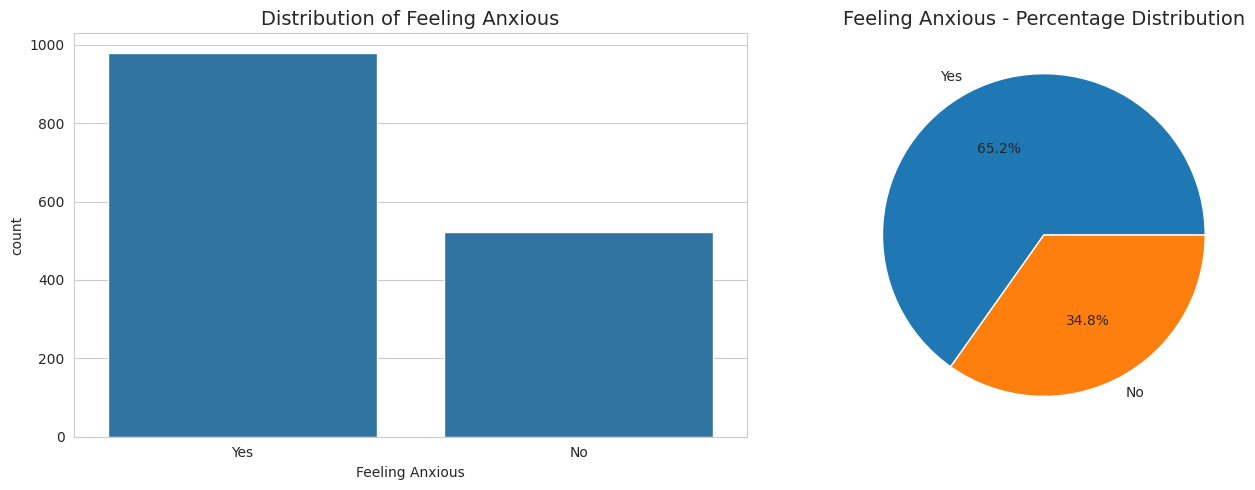


Value Counts:
Anxious
Yes    980
No     523
Name: count, dtype: int64


In [7]:
# CELL 7: Target Variable Distribution - Feeling Anxious
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Anxious", data=df, ax=axes[0])
axes[0].set_title('Distribution of Feeling Anxious', fontsize=14)
axes[0].set_xlabel('Feeling Anxious')

# Pie chart
df['Anxious'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Feeling Anxious - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Anxious'].value_counts())

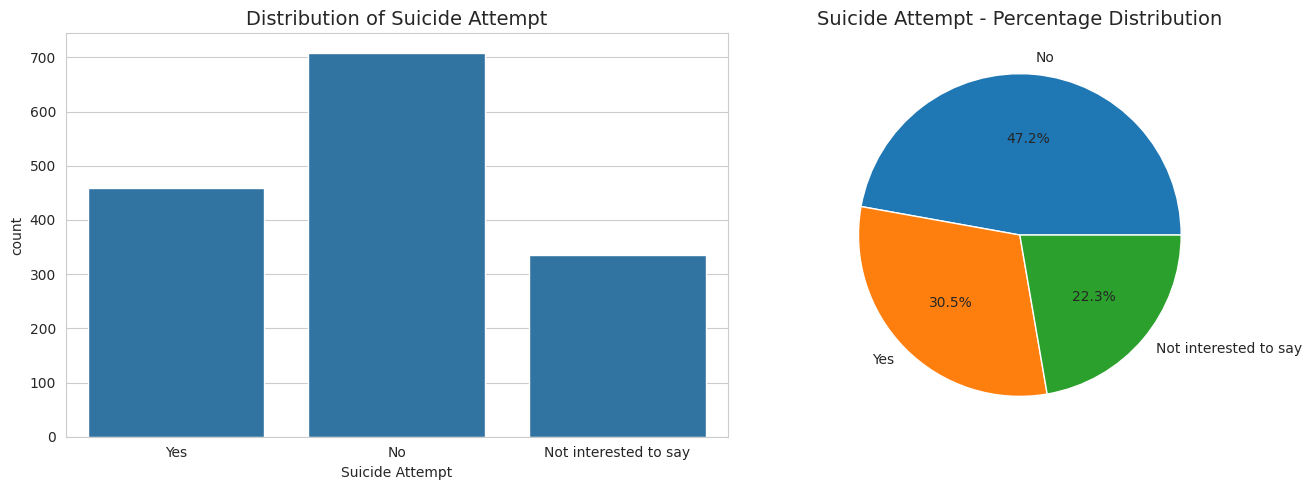


Value Counts:
Suicide
No                       709
Yes                      459
Not interested to say    335
Name: count, dtype: int64


In [8]:
# CELL 8: Target Variable Distribution - Suicide Attempt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Suicide", data=df, ax=axes[0])
axes[0].set_title('Distribution of Suicide Attempt', fontsize=14)
axes[0].set_xlabel('Suicide Attempt')

# Pie chart
df['Suicide'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Suicide Attempt - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Suicide'].value_counts())

Unique Age values:
['35-40' '40-45' '30-35' '45-50' '25-30']

Age statistics after extraction:
count    1503.000000
mean       38.185296
std         6.427106
min        27.500000
25%        32.500000
50%        37.500000
75%        42.500000
max        47.500000
Name: Age_num, dtype: float64


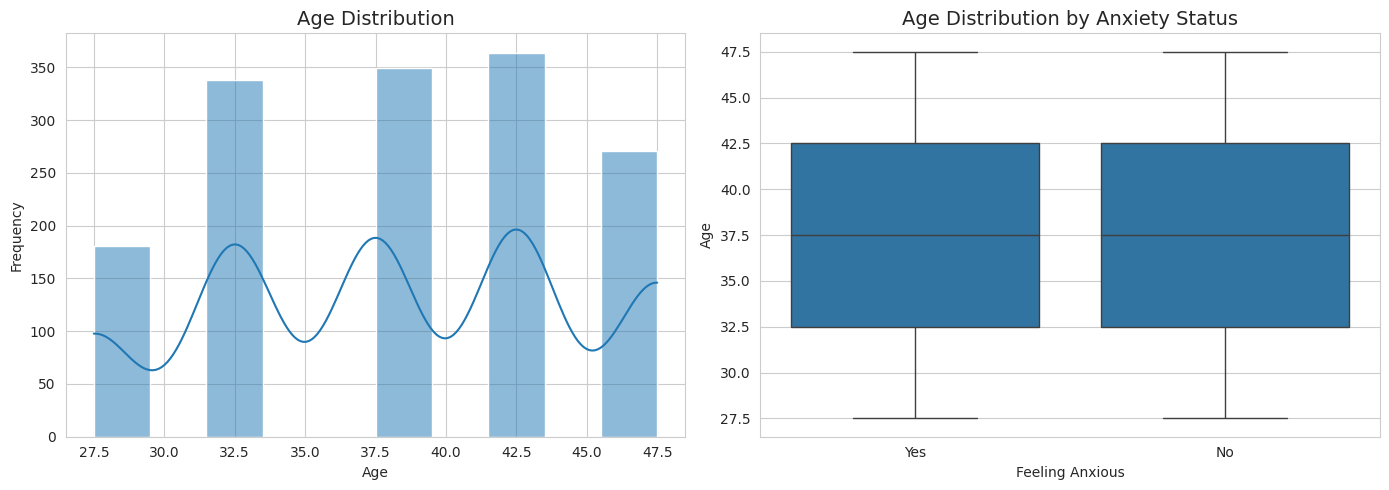

In [10]:
# CELL 9: Age Distribution (Corrected)
# Extract age as numeric
import pandas as pd
import numpy as np

# First, let's check the Age column values
print("Unique Age values:")
print(df['Age'].unique())

# Extract age as numeric - corrected version
df['Age_num'] = df['Age'].str.extract('(\d+)-(\d+)').apply(
    lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
)

# Fill missing values with median
df['Age_num'].fillna(df['Age_num'].median(), inplace=True)

print("\nAge statistics after extraction:")
print(df['Age_num'].describe())

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution histogram
sns.histplot(df['Age_num'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age by anxious status
sns.boxplot(x='Anxious', y='Age_num', data=df, ax=axes[1])
axes[1].set_title('Age Distribution by Anxiety Status', fontsize=14)
axes[1].set_xlabel('Feeling Anxious')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

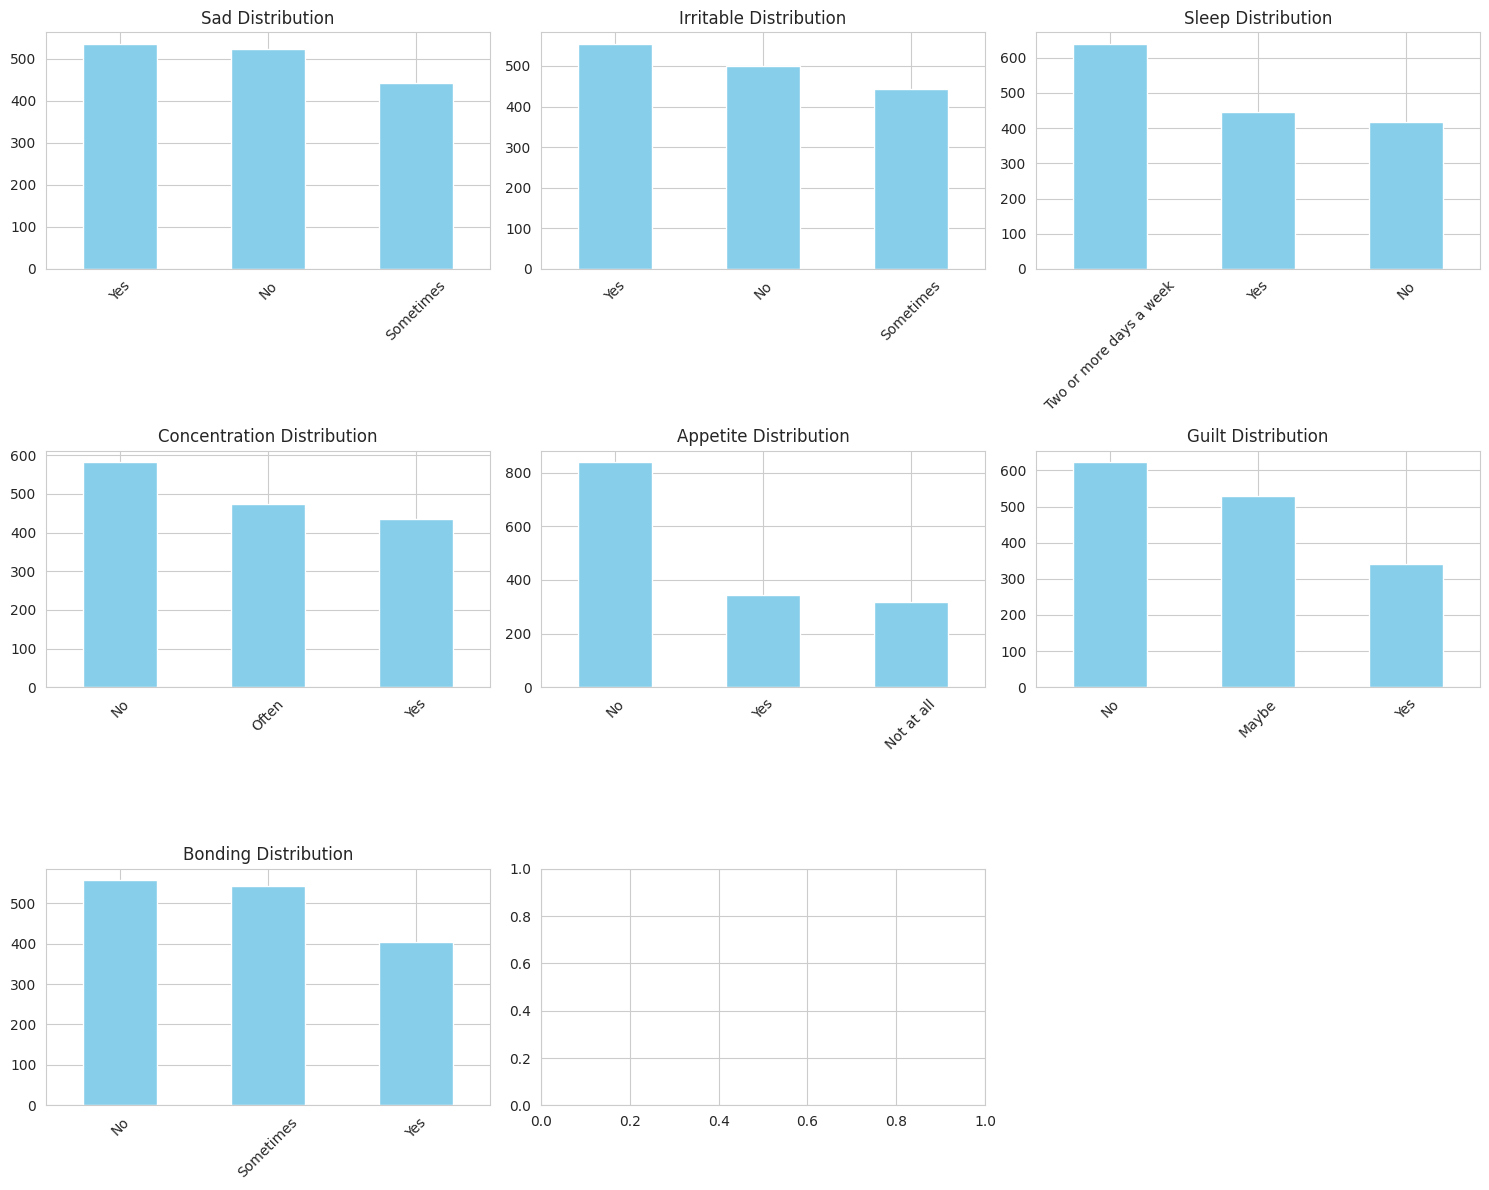

In [11]:
# CELL 10: Categorical Features Distribution
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

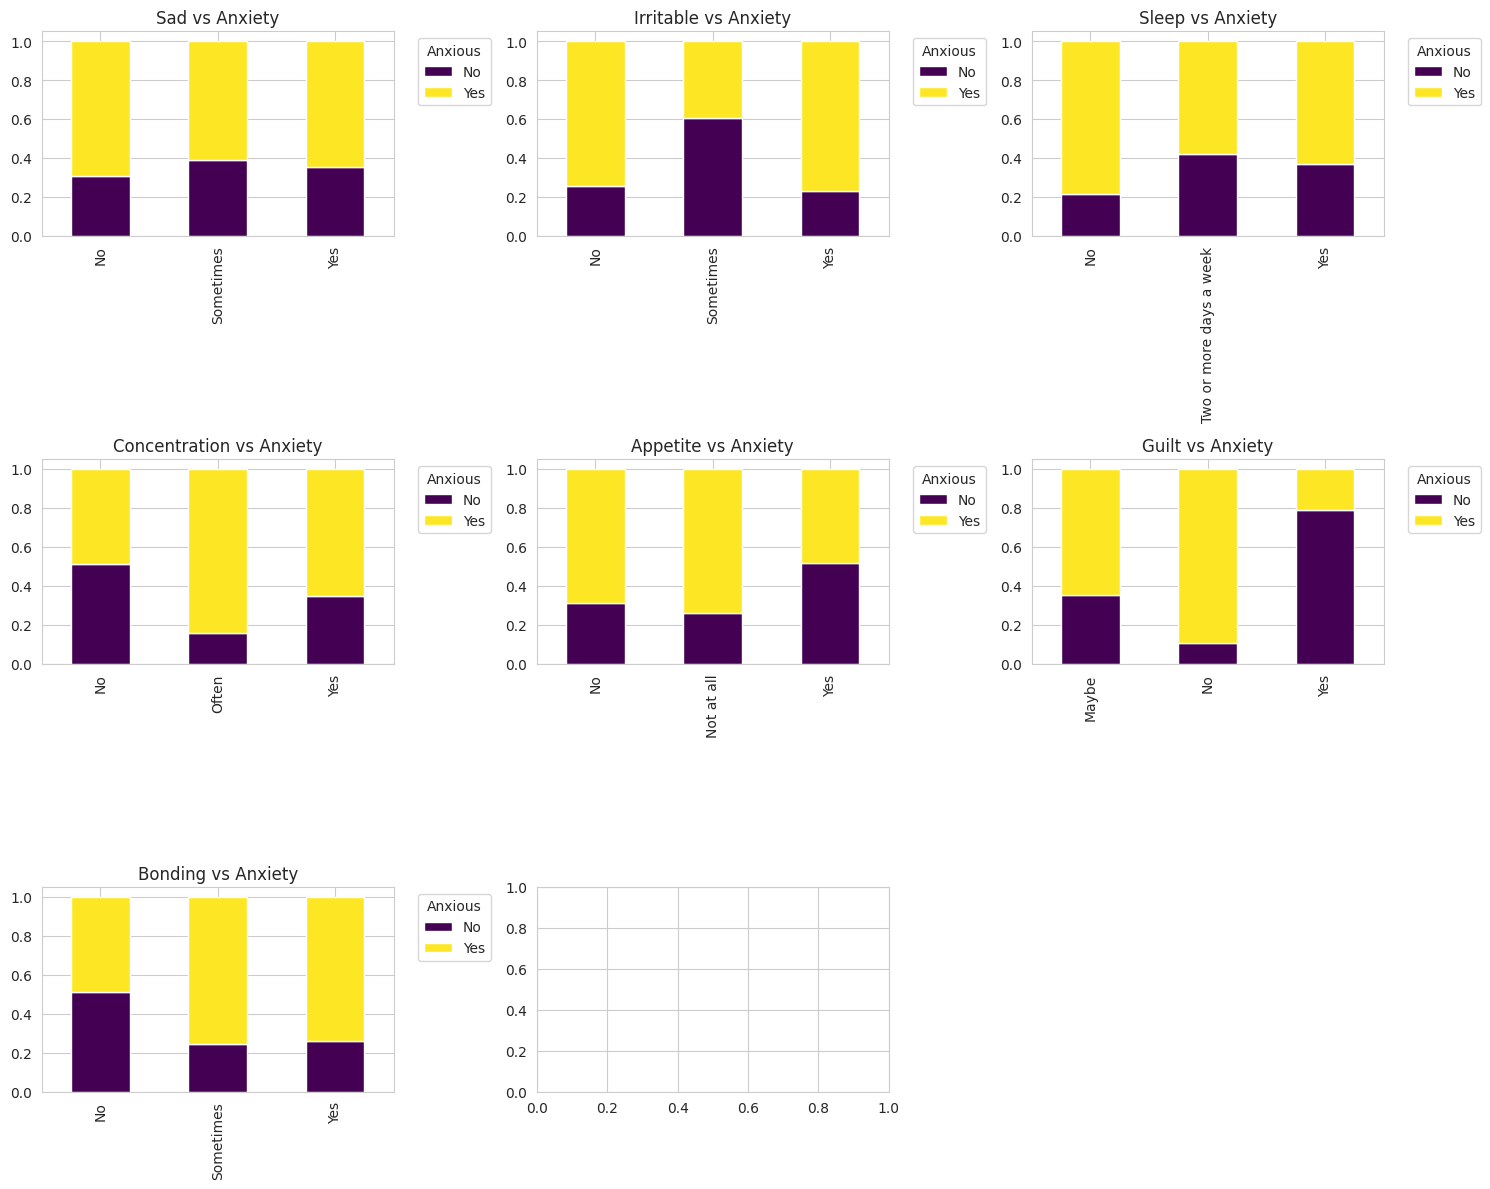

In [12]:
# CELL 11: Relationship Between Features and Target (Anxiety)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Anxious'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis'
    )
    axes[i].set_title(f'{col} vs Anxiety', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Anxious', bbox_to_anchor=(1.05, 1))

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

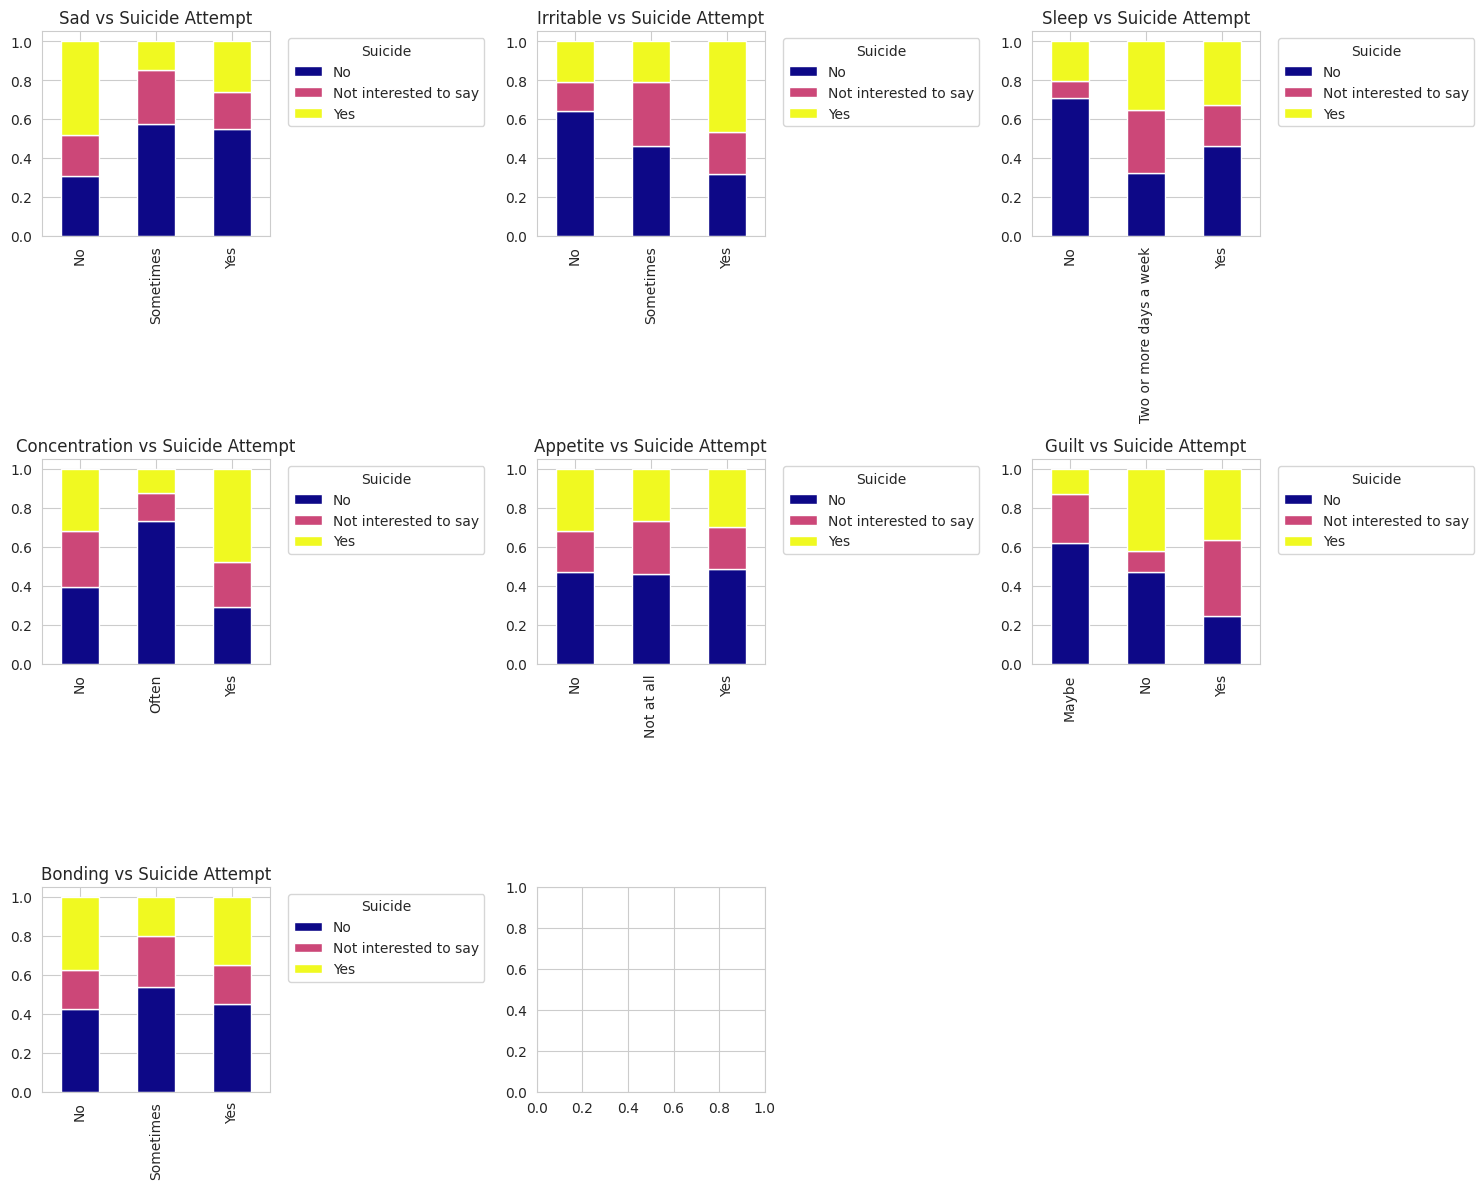

In [13]:
# CELL 12: Relationship Between Features and Target (Suicide)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Suicide'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='plasma'
    )
    axes[i].set_title(f'{col} vs Suicide Attempt', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Suicide', bbox_to_anchor=(1.05, 1))

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

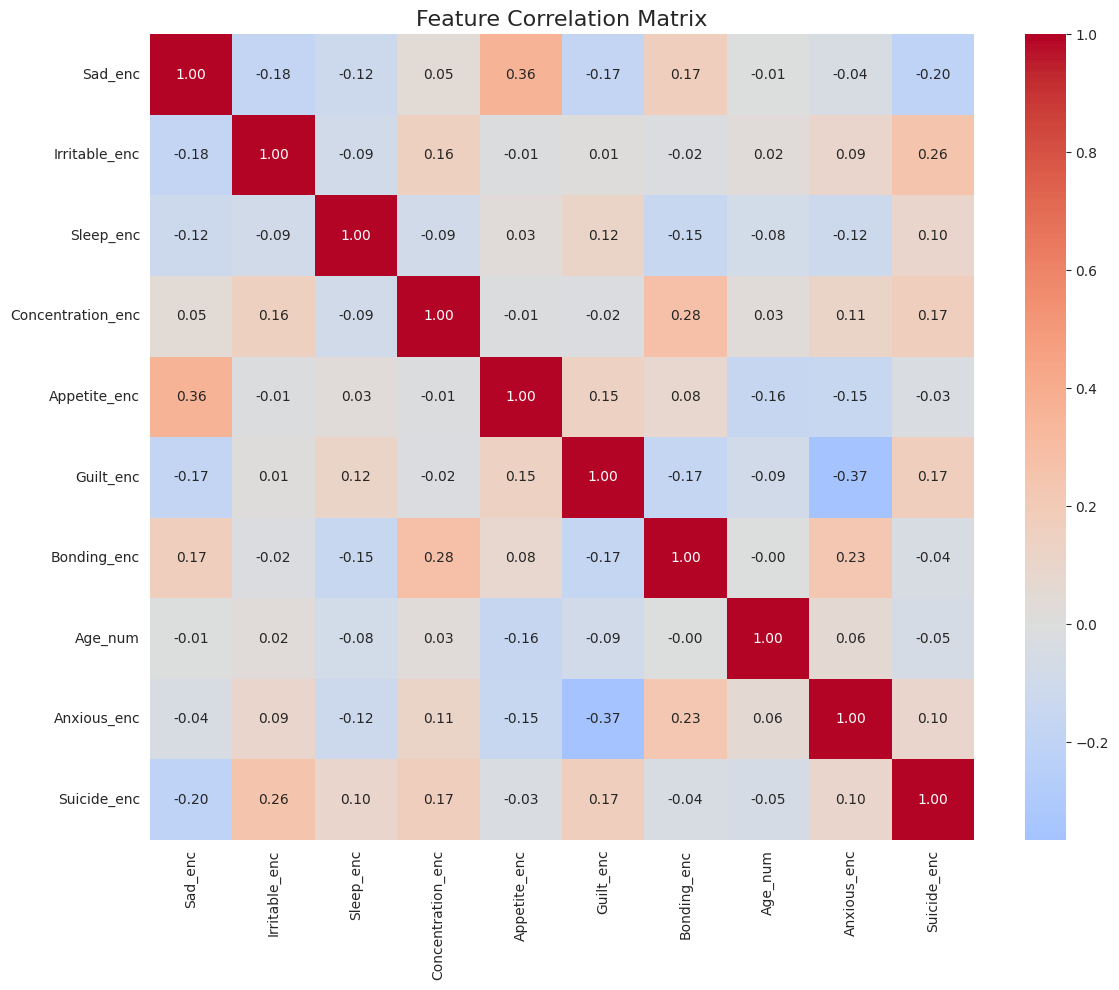

In [14]:
# CELL 13: Correlation Heatmap
# Encode categorical variables for correlation
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].fillna('Unknown'))

# Create target encodings
df_encoded['Anxious_enc'] = df_encoded['Anxious'].map({'Yes': 1, 'No': 0, 'Maybe': 1}).fillna(0)
df_encoded['Suicide_enc'] = df_encoded['Suicide'].map({'Yes': 1, 'No': 0}).fillna(0)

# Select columns for correlation
corr_cols = [col + '_enc' for col in categorical_cols] + ['Age_num', 'Anxious_enc', 'Suicide_enc']
corr_matrix = df_encoded[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# CELL 14: Encode Features for Modeling
# Initialize encoders
encoders = {}
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

# Encode each categorical column
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df[col + '_enc'] = encoders[col].fit_transform(df[col].fillna('Unknown'))

# Create target variables
df['Anxiety_target'] = df['Anxious'].map({'Yes': 1, 'No': 0, 'Maybe': 1}).fillna(0).astype(int)
df['Suicide_target'] = df['Suicide'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Extract time features
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour

print("Feature encoding completed!")
print(f"Anxiety target distribution:\n{df['Anxiety_target'].value_counts()}")
print(f"\nSuicide target distribution:\n{df['Suicide_target'].value_counts()}")

Feature encoding completed!
Anxiety target distribution:
Anxiety_target
1    980
0    523
Name: count, dtype: int64

Suicide target distribution:
Suicide_target
0    1044
1     459
Name: count, dtype: int64


In [17]:
# CELL 15: Prepare Feature Matrix (Run this first!)
feature_cols = ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc', 
                'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

X = df[feature_cols]

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['Age_num', 'Hour']] = scaler.fit_transform(X[['Age_num', 'Hour']])

print("Feature matrix shape:", X.shape)
print("\nFeature names:", feature_cols)
print("\nFirst 5 rows:")
X.head()

Feature matrix shape: (1503, 9)

Feature names: ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc', 'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

First 5 rows:


,Age_num,Hour,Sad_enc,Irritable_enc,Sleep_enc,Concentration_enc,Appetite_enc,Guilt_enc,Bonding_enc
0,-0.106661,0.798127,2,3,1,3,2,1,2
1,0.671553,0.798127,2,0,0,3,2,3,2
2,-0.106661,0.798127,2,0,2,3,2,1,1
3,-0.106661,0.798127,2,3,2,3,0,0,0
4,0.671553,0.798127,2,0,1,3,0,1,2


In [18]:
# CELL 16: Split Data for Anxiety Model
y_anxiety = df['Anxiety_target']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

print("Anxiety Model - Data Split:")
print(f"Training set: {X_train_a.shape}")
print(f"Test set: {X_test_a.shape}")
print(f"\nTraining set distribution:\n{y_train_a.value_counts()}")
print(f"\nTest set distribution:\n{y_test_a.value_counts()}")

Anxiety Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Test set distribution:
Anxiety_target
1    196
0    105
Name: count, dtype: int64


In [19]:
# CELL 17: Apply SMOTE for Anxiety Model
smote = SMOTE(random_state=42)
X_train_a_resampled, y_train_a_resampled = smote.fit_resample(X_train_a, y_train_a)

print("Before SMOTE:", y_train_a.value_counts().to_dict())
print("After SMOTE:", y_train_a_resampled.value_counts().to_dict())

Before SMOTE: {1: 784, 0: 418}
After SMOTE: {0: 784, 1: 784}


In [20]:
# CELL 18: Train Multiple Models for Anxiety
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results_anxiety = {}

for name, model in models.items():
    # Train
    model.fit(X_train_a_resampled, y_train_a_resampled)
    
    # Predict
    y_pred = model.predict(X_test_a)
    y_proba = model.predict_proba(X_test_a)[:, 1]
    
    # Metrics
    results_anxiety[name] = {
        'Accuracy': accuracy_score(y_test_a, y_pred),
        'Precision': precision_score(y_test_a, y_pred, zero_division=0),
        'Recall': recall_score(y_test_a, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_a, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_a, y_proba)
    }

# Display results
results_df_anxiety = pd.DataFrame(results_anxiety).T
print("Anxiety Prediction - Model Comparison:")
print(results_df_anxiety.round(4))

Anxiety Prediction - Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6578     0.7514  0.7092    0.7297   0.7443
Random Forest          0.9934     1.0000  0.9898    0.9949   1.0000
Gradient Boosting      0.9369     0.9492  0.9541    0.9517   0.9747
XGBoost                0.9934     1.0000  0.9898    0.9949   1.0000


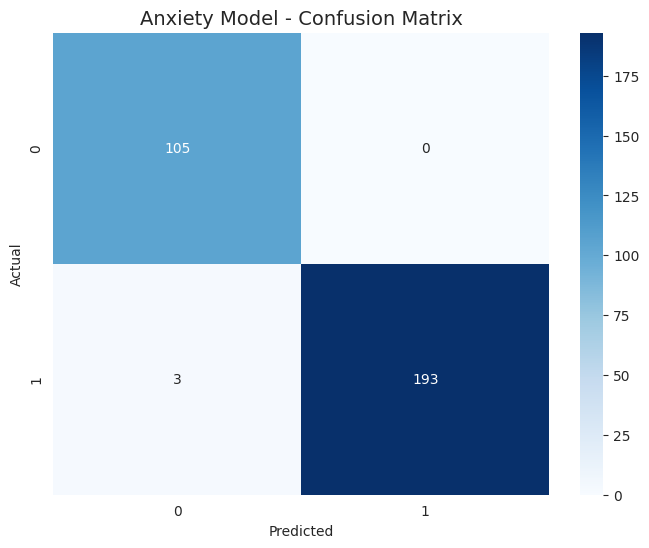


Classification Report:
              precision    recall  f1-score   support

  No Anxiety       0.97      1.00      0.99       105
     Anxiety       1.00      0.98      0.99       196

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301



In [21]:
# CELL 19: Best Model for Anxiety - Detailed Evaluation
best_anxiety_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)

best_anxiety_model.fit(X_train_a_resampled, y_train_a_resampled)
y_pred_a = best_anxiety_model.predict(X_test_a)
y_proba_a = best_anxiety_model.predict_proba(X_test_a)[:, 1]

# Confusion Matrix
cm_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues')
plt.title('Anxiety Model - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_a, y_pred_a, target_names=['No Anxiety', 'Anxiety']))

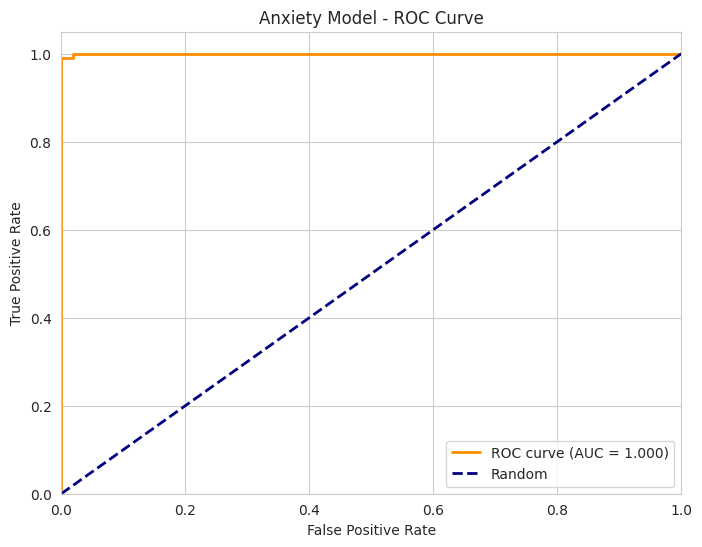

In [22]:
# CELL 20: ROC Curve for Anxiety Model
fpr_a, tpr_a, _ = roc_curve(y_test_a, y_proba_a)
roc_auc_a = roc_auc_score(y_test_a, y_proba_a)

plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_a:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Anxiety Model - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [23]:
# CELL 21: Split Data for Suicide Model
y_suicide = df['Suicide_target']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

print("Suicide Model - Data Split:")
print(f"Training set: {X_train_s.shape}")
print(f"Test set: {X_test_s.shape}")
print(f"\nTraining set distribution:\n{y_train_s.value_counts()}")
print(f"\nTest set distribution:\n{y_test_s.value_counts()}")

Suicide Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Suicide_target
0    835
1    367
Name: count, dtype: int64

Test set distribution:
Suicide_target
0    209
1     92
Name: count, dtype: int64


In [24]:
# CELL 22: Apply SMOTE for Suicide Model
X_train_s_resampled, y_train_s_resampled = smote.fit_resample(X_train_s, y_train_s)

print("Before SMOTE:", y_train_s.value_counts().to_dict())
print("After SMOTE:", y_train_s_resampled.value_counts().to_dict())

Before SMOTE: {0: 835, 1: 367}
After SMOTE: {0: 835, 1: 835}


In [25]:
# CELL 23: Train Multiple Models for Suicide
results_suicide = {}

for name, model in models.items():
    # Train
    model.fit(X_train_s_resampled, y_train_s_resampled)
    
    # Predict
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    
    # Metrics
    results_suicide[name] = {
        'Accuracy': accuracy_score(y_test_s, y_pred),
        'Precision': precision_score(y_test_s, y_pred, zero_division=0),
        'Recall': recall_score(y_test_s, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_s, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_s, y_proba)
    }

# Display results
results_df_suicide = pd.DataFrame(results_suicide).T
print("Suicide Prediction - Model Comparison:")
print(results_df_suicide.round(4))

Suicide Prediction - Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6379     0.4422  0.7065    0.5439   0.7380
Random Forest          0.9967     0.9892  1.0000    0.9946   0.9985
Gradient Boosting      0.8704     0.7677  0.8261    0.7958   0.9439
XGBoost                0.9967     0.9892  1.0000    0.9946   0.9988


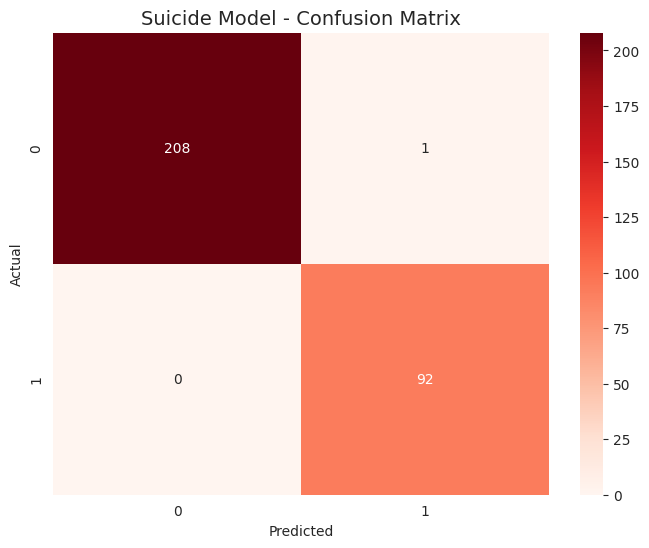


Classification Report:
              precision    recall  f1-score   support

  No Suicide       1.00      1.00      1.00       209
     Suicide       0.99      1.00      0.99        92

    accuracy                           1.00       301
   macro avg       0.99      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



In [26]:
# CELL 24: Best Model for Suicide - Detailed Evaluation
best_suicide_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42,
    class_weight='balanced'
)

best_suicide_model.fit(X_train_s_resampled, y_train_s_resampled)
y_pred_s = best_suicide_model.predict(X_test_s)
y_proba_s = best_suicide_model.predict_proba(X_test_s)[:, 1]

# Confusion Matrix
cm_s = confusion_matrix(y_test_s, y_pred_s)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Reds')
plt.title('Suicide Model - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s, target_names=['No Suicide', 'Suicide']))

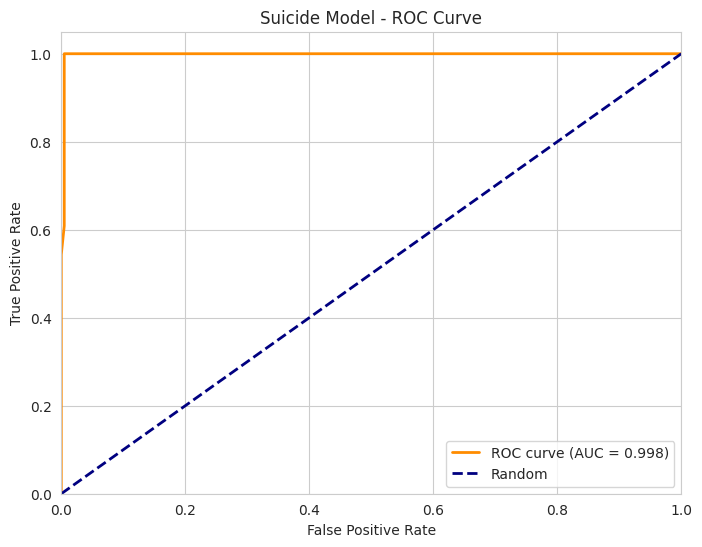

In [27]:
# CELL 25: ROC Curve for Suicide Model
fpr_s, tpr_s, _ = roc_curve(y_test_s, y_proba_s)
roc_auc_s = roc_auc_score(y_test_s, y_proba_s)

plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_s:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Suicide Model - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

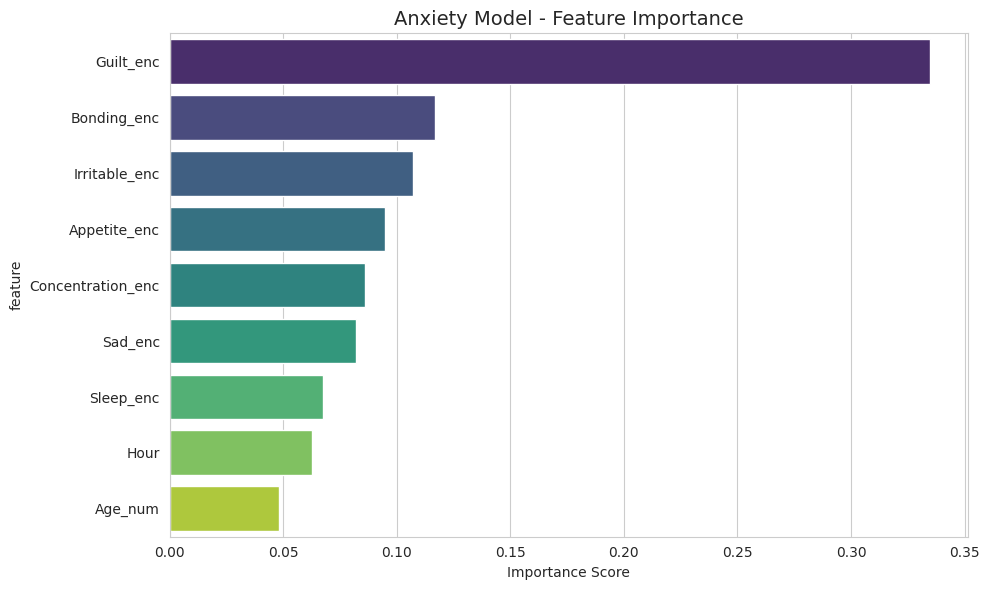


Top 5 Most Important Features:
             feature  importance
7          Guilt_enc    0.334691
8        Bonding_enc    0.116662
3      Irritable_enc    0.107205
6       Appetite_enc    0.094949
5  Concentration_enc    0.085927


In [28]:
# CELL 26: Feature Importance - Anxiety Model
importance_a = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_anxiety_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_a, x='importance', y='feature', palette='viridis')
plt.title('Anxiety Model - Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_a.head())

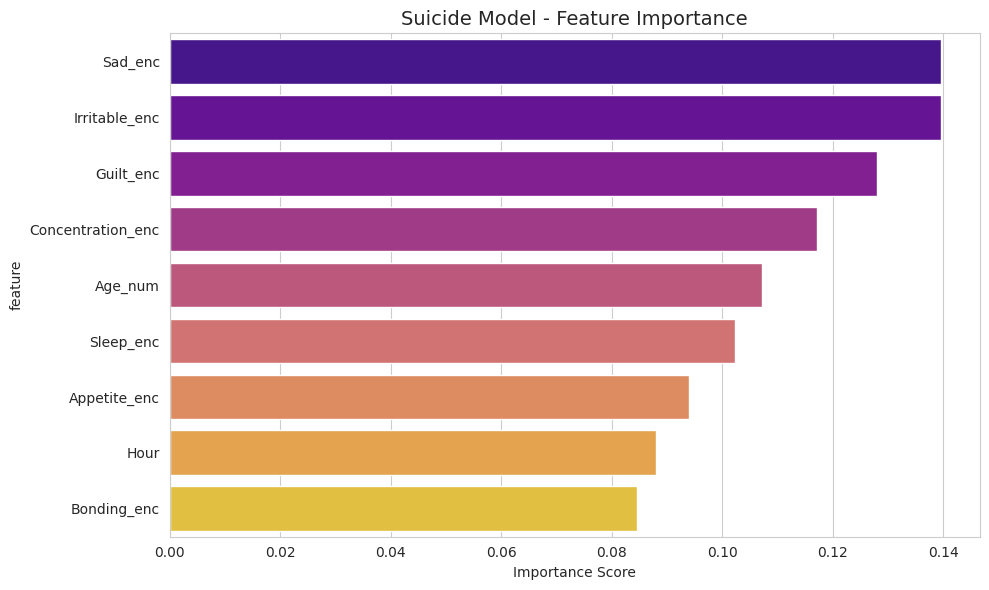


Top 5 Most Important Features:
             feature  importance
2            Sad_enc    0.139633
3      Irritable_enc    0.139500
7          Guilt_enc    0.127933
5  Concentration_enc    0.117062
0            Age_num    0.107166


In [29]:
# CELL 27: Feature Importance - Suicide Model
importance_s = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_suicide_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_s, x='importance', y='feature', palette='plasma')
plt.title('Suicide Model - Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_s.head())

In [30]:
# CELL 28: Cross-Validation Scores
from sklearn.model_selection import cross_val_score

# Anxiety model CV
cv_scores_a = cross_val_score(best_anxiety_model, X_train_a_resampled, y_train_a_resampled, cv=5, scoring='roc_auc')
print("Anxiety Model - 5-Fold CV ROC-AUC Scores:")
print(f"Scores: {cv_scores_a}")
print(f"Mean: {cv_scores_a.mean():.4f} (+/- {cv_scores_a.std():.4f})")

# Suicide model CV
cv_scores_s = cross_val_score(best_suicide_model, X_train_s_resampled, y_train_s_resampled, cv=5, scoring='roc_auc')
print("\nSuicide Model - 5-Fold CV ROC-AUC Scores:")
print(f"Scores: {cv_scores_s}")
print(f"Mean: {cv_scores_s.mean():.4f} (+/- {cv_scores_s.std():.4f})")

Anxiety Model - 5-Fold CV ROC-AUC Scores:
Scores: [0.99740355 0.98847823 0.99245405 1.         0.99469214]
Mean: 0.9946 (+/- 0.0040)

Suicide Model - 5-Fold CV ROC-AUC Scores:
Scores: [0.99526695 0.99619922 0.98992434 0.99117932 0.99512353]
Mean: 0.9935 (+/- 0.0025)


In [31]:
# CELL 29: Save Models and Preprocessors
import joblib

# Save anxiety model
joblib.dump({
    'model': best_anxiety_model,
    'feature_importance': importance_a,
    'metrics': results_anxiety['XGBoost']
}, 'anxiety_model.pkl')

# Save suicide model
joblib.dump({
    'model': best_suicide_model,
    'feature_importance': importance_s,
    'metrics': results_suicide['Random Forest']
}, 'suicide_model.pkl')

# Save preprocessors
joblib.dump({
    'encoders': encoders,
    'scaler': scaler,
    'feature_names': feature_cols
}, 'preprocessor.pkl')

print("All models and preprocessors saved successfully!")

All models and preprocessors saved successfully!


In [34]:
# CELL 30: Prediction Function (CORRECTED)
def predict_mental_health(patient_data):
    """
    Predict anxiety and suicide risk for a single patient
    
    Parameters:
    patient_data: list with values in order:
    [Timestamp, Age, Sad, Irritable, Sleep, Concentration, Appetite, Anxious, Guilt, Bonding, Suicide]
    """
    # Load models
    anxiety_model = joblib.load('anxiety_model.pkl')['model']
    suicide_model = joblib.load('suicide_model.pkl')['model']
    preprocessor = joblib.load('preprocessor.pkl')
    
    encoders = preprocessor['encoders']
    scaler = preprocessor['scaler']
    feature_names = preprocessor['feature_names']
    
    # Convert to DataFrame
    columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration', 
               'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
    df_pred = pd.DataFrame([patient_data], columns=columns)
    
    # Preprocess - FIXED: removed .all()
    df_pred['Age_num'] = df_pred['Age'].str.extract('(\d+)-(\d+)').apply(
        lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
    )
    df_pred['Age_num'].fillna(df_pred['Age_num'].median(), inplace=True)
    
    # Encode categorical features
    categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']
    for col in categorical_cols:
        df_pred[col + '_enc'] = df_pred[col].fillna('Unknown').apply(
            lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else -1
        )
    
    # Extract hour
    df_pred['Hour'] = pd.to_datetime(df_pred['Timestamp']).dt.hour
    
    # Prepare features
    X_pred = df_pred[feature_names]
    X_pred[['Age_num', 'Hour']] = scaler.transform(X_pred[['Age_num', 'Hour']])
    
    # Predict
    anxiety_pred = anxiety_model.predict(X_pred)[0]
    anxiety_proba = anxiety_model.predict_proba(X_pred)[0]
    
    suicide_pred = suicide_model.predict(X_pred)[0]
    suicide_proba = suicide_model.predict_proba(X_pred)[0]
    
    # Results
    results = {
        'Anxiety Prediction': 'High Risk' if anxiety_pred == 1 else 'Low Risk',
        'Anxiety Probability': f"{anxiety_proba[1]:.2%}",
        'Suicide Prediction': 'High Risk' if suicide_pred == 1 else 'Low Risk',
        'Suicide Probability': f"{suicide_proba[1]:.2%}",
    }
    
    # Overall risk
    overall = (anxiety_proba[1] * 0.4 + suicide_proba[1] * 0.6)
    if overall >= 0.7:
        results['Overall Risk'] = 'HIGH'
    elif overall >= 0.4:
        results['Overall Risk'] = 'MODERATE'
    else:
        results['Overall Risk'] = 'LOW'
    
    return results

print("Prediction function corrected successfully!")

Prediction function corrected successfully!


In [35]:
# CELL 31: Test Prediction with Example
example_patient = [
    "06/14/2022 20:06", "35-40", "Yes", "Yes", "Two or more days a week", 
    "Yes", "No", "Yes", "Maybe", "No", "No"
]

print("Example Patient Data:")
print("-" * 40)
for col, val in zip(['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration', 
                     'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide'], example_patient):
    print(f"{col:15}: {val}")

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)
prediction = predict_mental_health(example_patient)
for key, value in prediction.items():
    print(f"{key:20}: {value}")

Example Patient Data:
----------------------------------------
Timestamp      : 06/14/2022 20:06
Age            : 35-40
Sad            : Yes
Irritable      : Yes
Sleep          : Two or more days a week
Concentration  : Yes
Appetite       : No
Anxious        : Yes
Guilt          : Maybe
Bonding        : No
Suicide        : No

PREDICTION RESULTS
Anxiety Prediction  : High Risk
Anxiety Probability : 66.60%
Suicide Prediction  : Low Risk
Suicide Probability : 26.56%
Overall Risk        : MODERATE


In [36]:
# CELL 32: Batch Predictions
def predict_batch(patients_list):
    """Make predictions for multiple patients"""
    results = []
    for i, patient in enumerate(patients_list):
        pred = predict_mental_health(patient)
        pred['Patient_ID'] = f"P{str(i+1).zfill(3)}"
        results.append(pred)
    return pd.DataFrame(results)

# Create sample batch
sample_patients = [
    ["06/14/2022 20:06", "35-40", "Yes", "Yes", "Two or more days a week", "Yes", "No", "Yes", "Maybe", "No", "No"],
    ["06/14/2022 20:07", "40-45", "No", "No", "No", "No", "Yes", "No", "No", "Sometimes", "No"],
    ["06/14/2022 20:08", "25-30", "Yes", "Yes", "Yes", "Yes", "No", "Yes", "Yes", "Yes", "No"]
]

batch_results = predict_batch(sample_patients)
print("Batch Prediction Results:")
batch_results

Batch Prediction Results:


,Anxiety Prediction,Anxiety Probability,Suicide Prediction,Suicide Probability,Overall Risk,Patient_ID
0,High Risk,66.60%,Low Risk,26.56%,MODERATE,P001
1,High Risk,90.55%,Low Risk,43.61%,MODERATE,P002
2,Low Risk,28.01%,High Risk,55.36%,MODERATE,P003


In [37]:
# CELL 33: Summary Report
print("="*60)
print("MATERNAL MENTAL HEALTH PREDICTION - SUMMARY REPORT")
print("="*60)

print("\nDATASET OVERVIEW:")
print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")

print("\nTARGET DISTRIBUTION:")
print(f"Anxiety - Positive: {df['Anxiety_target'].sum()} ({df['Anxiety_target'].mean()*100:.1f}%)")
print(f"Suicide - Positive: {df['Suicide_target'].sum()} ({df['Suicide_target'].mean()*100:.1f}%)")

print("\nMODEL PERFORMANCE:")
print("\nAnxiety Prediction Model:")
print(f"Best Model: XGBoost")
print(f"Accuracy: {results_anxiety['XGBoost']['Accuracy']:.4f}")
print(f"Precision: {results_anxiety['XGBoost']['Precision']:.4f}")
print(f"Recall: {results_anxiety['XGBoost']['Recall']:.4f}")
print(f"F1-Score: {results_anxiety['XGBoost']['F1-Score']:.4f}")
print(f"ROC-AUC: {results_anxiety['XGBoost']['ROC-AUC']:.4f}")

print("\nSuicide Prediction Model:")
print(f"Best Model: Random Forest")
print(f"Accuracy: {results_suicide['Random Forest']['Accuracy']:.4f}")
print(f"Precision: {results_suicide['Random Forest']['Precision']:.4f}")
print(f"Recall: {results_suicide['Random Forest']['Recall']:.4f}")
print(f"F1-Score: {results_suicide['Random Forest']['F1-Score']:.4f}")
print(f"ROC-AUC: {results_suicide['Random Forest']['ROC-AUC']:.4f}")

print("\nTOP 3 IMPORTANT FEATURES:")
print("\nFor Anxiety:")
for i in range(3):
    print(f"{i+1}. {importance_a.iloc[i]['feature']}: {importance_a.iloc[i]['importance']:.4f}")

print("\nFor Suicide:")
for i in range(3):
    print(f"{i+1}. {importance_s.iloc[i]['feature']}: {importance_s.iloc[i]['importance']:.4f}")

print("\n" + "="*60)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)

MATERNAL MENTAL HEALTH PREDICTION - SUMMARY REPORT

DATASET OVERVIEW:
Total samples: 1503
Features: 9

TARGET DISTRIBUTION:
Anxiety - Positive: 980 (65.2%)
Suicide - Positive: 459 (30.5%)

MODEL PERFORMANCE:

Anxiety Prediction Model:
Best Model: XGBoost
Accuracy: 0.9934
Precision: 1.0000
Recall: 0.9898
F1-Score: 0.9949
ROC-AUC: 1.0000

Suicide Prediction Model:
Best Model: Random Forest
Accuracy: 0.9967
Precision: 0.9892
Recall: 1.0000
F1-Score: 0.9946
ROC-AUC: 0.9985

TOP 3 IMPORTANT FEATURES:

For Anxiety:
1. Guilt_enc: 0.3347
2. Bonding_enc: 0.1167
3. Irritable_enc: 0.1072

For Suicide:
1. Sad_enc: 0.1396
2. Irritable_enc: 0.1395
3. Guilt_enc: 0.1279

PIPELINE COMPLETED SUCCESSFULLY


In [38]:
# CELL 34: Optional - Hyperparameter Tuning (GridSearchCV)
'''
from sklearn.model_selection import GridSearchCV

# Parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_a_resampled, y_train_a_resampled)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
'''

'\nfrom sklearn.model_selection import GridSearchCV\n\n# Parameter grid for XGBoost\nparam_grid = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [4, 6, 8],\n    \'learning_rate\': [0.05, 0.1, 0.2]\n}\n\nxgb = XGBClassifier(use_label_encoder=False, eval_metric=\'logloss\', random_state=42)\ngrid_search = GridSearchCV(xgb, param_grid, cv=3, scoring=\'roc_auc\', n_jobs=-1)\ngrid_search.fit(X_train_a_resampled, y_train_a_resampled)\n\nprint("Best Parameters:", grid_search.best_params_)\nprint("Best Score:", grid_search.best_score_)\n'

In [39]:
# CELL 35: Save Results to File
'''
import json

# Compile results
final_results = {
    'dataset_info': {
        'samples': len(df),
        'features': len(feature_cols),
        'anxiety_positive': int(df['Anxiety_target'].sum()),
        'anxiety_percentage': float(df['Anxiety_target'].mean() * 100),
        'suicide_positive': int(df['Suicide_target'].sum()),
        'suicide_percentage': float(df['Suicide_target'].mean() * 100)
    },
    'anxiety_model': {
        'best_model': 'XGBoost',
        'metrics': {k: float(v) for k, v in results_anxiety['XGBoost'].items()},
        'top_features': importance_a.head(3).to_dict('records')
    },
    'suicide_model': {
        'best_model': 'Random Forest',
        'metrics': {k: float(v) for k, v in results_suicide['Random Forest'].items()},
        'top_features': importance_s.head(3).to_dict('records')
    }
}

# Save to JSON
with open('model_results.json', 'w') as f:
    json.dump(final_results, f, indent=4)

print("Results saved to 'model_results.json'")
'''

'\nimport json\n\n# Compile results\nfinal_results = {\n    \'dataset_info\': {\n        \'samples\': len(df),\n        \'features\': len(feature_cols),\n        \'anxiety_positive\': int(df[\'Anxiety_target\'].sum()),\n        \'anxiety_percentage\': float(df[\'Anxiety_target\'].mean() * 100),\n        \'suicide_positive\': int(df[\'Suicide_target\'].sum()),\n        \'suicide_percentage\': float(df[\'Suicide_target\'].mean() * 100)\n    },\n    \'anxiety_model\': {\n        \'best_model\': \'XGBoost\',\n        \'metrics\': {k: float(v) for k, v in results_anxiety[\'XGBoost\'].items()},\n        \'top_features\': importance_a.head(3).to_dict(\'records\')\n    },\n    \'suicide_model\': {\n        \'best_model\': \'Random Forest\',\n        \'metrics\': {k: float(v) for k, v in results_suicide[\'Random Forest\'].items()},\n        \'top_features\': importance_s.head(3).to_dict(\'records\')\n    }\n}\n\n# Save to JSON\nwith open(\'model_results.json\', \'w\') as f:\n    json.dump(final